 ## Классификация

Загружаем датасеты в память

In [1]:
import os
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("/content")
cls_path = DATA_DIR / "car_evaluation.csv"
REG_PATH = DATA_DIR / "CarPrice_Assignment.csv"
col_names = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
def load_car_evaluation(path):
    df = pd.read_csv(path, header=None, names=col_names, dtype=str)
    for c in df.columns:
        df[c] = df[c].str.strip().str.lower()
    return df

df_cls = load_car_evaluation(cls_path)
print(df_cls.head(5))
print("Shape:", df_cls.shape)
print("Target distribution:\n", df_cls['class'].value_counts())


  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc
Shape: (1728, 7)
Target distribution:
 class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


Деление на трейн и тест

In [2]:
X_cls = df_cls.drop(columns=['class'])
y_cls = df_cls['class']
print("Class proportions:\n", y_cls.value_counts(normalize=True))

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls
)
print("Train size:", X_train_cls.shape, "| Test size:", X_test_cls.shape)


Class proportions:
 class
unacc    0.700231
acc      0.222222
good     0.039931
vgood    0.037616
Name: proportion, dtype: float64
Train size: (1382, 6) | Test size: (346, 6)


Датасет небольшой, решающее дерево должно хорошо справиться с такой задачей

[DT Classifier — baseline]  Acc=0.9740 | F1-macro=0.9450
              precision    recall  f1-score   support

         acc     0.9595    0.9221    0.9404        77
        good     0.8750    1.0000    0.9333        14
       unacc     0.9837    0.9959    0.9897       242
       vgood     1.0000    0.8462    0.9167        13

    accuracy                         0.9740       346
   macro avg     0.9545    0.9410    0.9450       346
weighted avg     0.9745    0.9740    0.9737       346



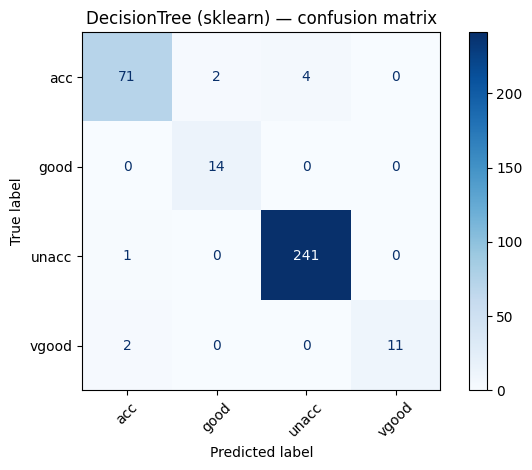

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cat_cols = list(X_train_cls.columns)

prep_cls = ColumnTransformer([
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
], remainder="drop")

dtc_base = Pipeline([
    ("prep", prep_cls),
    ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

dtc_base.fit(X_train_cls, y_train_cls)
y_pred = dtc_base.predict(X_test_cls)

print(f"[DT Classifier — baseline]  Acc={accuracy_score(y_test_cls, y_pred):.4f} | F1-macro={f1_score(y_test_cls, y_pred, average='macro'):.4f}")
print(classification_report(y_test_cls, y_pred, digits=4))
ConfusionMatrixDisplay.from_predictions(y_test_cls, y_pred, xticks_rotation=45, cmap="Blues")
plt.title("DecisionTree (sklearn) — confusion matrix")
plt.tight_layout(); plt.show()


Найдем оптимиальные параметры гридсерчем

Best params: {'dt__criterion': 'entropy', 'dt__max_depth': None, 'dt__max_features': None, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}
[DT Classifier — tuned]     Acc=0.9913 | F1-macro=0.9684
              precision    recall  f1-score   support

         acc     0.9868    0.9740    0.9804        77
        good     0.8750    1.0000    0.9333        14
       unacc     1.0000    1.0000    1.0000       242
       vgood     1.0000    0.9231    0.9600        13

    accuracy                         0.9913       346
   macro avg     0.9655    0.9743    0.9684       346
weighted avg     0.9920    0.9913    0.9914       346



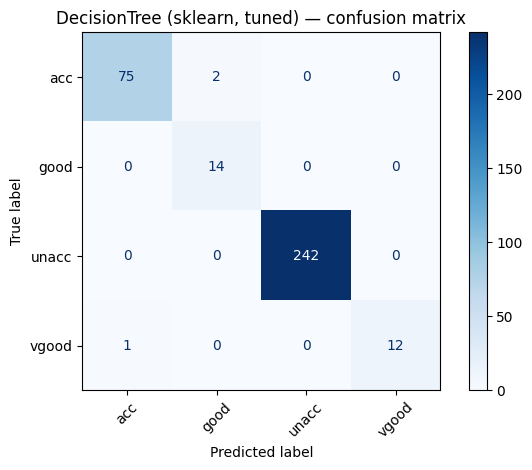

In [4]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid_cls = {
    "dt__criterion": ["gini", "entropy", "log_loss"],
    "dt__max_depth": [None, 4, 6, 8, 10, 12],
    "dt__min_samples_split": [2, 5, 10],
    "dt__min_samples_leaf": [1, 2, 5],
    "dt__max_features": [None, "sqrt", "log2", 0.5, 0.8]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
dtc_grid = GridSearchCV(
    dtc_base, param_grid=param_grid_cls,
    scoring={"f1_macro":"f1_macro", "accuracy":"accuracy"},
    refit="f1_macro", cv=cv, n_jobs=-1, verbose=0
)
dtc_grid.fit(X_train_cls, y_train_cls)
yp = dtc_grid.predict(X_test_cls)

print("Best params:", dtc_grid.best_params_)
print(f"[DT Classifier — tuned]     Acc={accuracy_score(y_test_cls, yp):.4f} | F1-macro={f1_score(y_test_cls, yp, average='macro'):.4f}")
print(classification_report(y_test_cls, yp, digits=4))
ConfusionMatrixDisplay.from_predictions(y_test_cls, yp, xticks_rotation=45, cmap="Blues")
plt.title("DecisionTree (sklearn, tuned) — confusion matrix")
plt.tight_layout(); plt.show()


# Регрессия

In [5]:
from sklearn.preprocessing import MinMaxScaler

def load_car_price_assignment(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    y = df["price"]
    X = df.drop(columns=["price", "car_ID"])
    # Выделяем бренд из имени модели
    if "CarName" in X.columns:
        carnames = X["CarName"].astype(str).str.strip().str.lower()
        X["brand"] = carnames.str.split("[ \-]", n=1, expand=True)[0]
        X = X.drop(columns=["CarName"])
    # Конвертация слов-чисел в числа (doornumber, cylindernumber)
    NUM_WORDS = {'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12}
    for col in ["doornumber", "cylindernumber"]:
        if col in X.columns and X[col].dtype == object:
            X[col] = X[col].str.strip().str.lower().map(NUM_WORDS).astype("Int64")
    for c in X.columns:
        if X[c].dtype == object:
            X[c] = X[c].astype(str).str.strip().str.lower()
    return X, y

X_reg_raw, y_reg_raw = load_car_price_assignment(REG_PATH)
print("Regression dataset shape:", X_reg_raw.shape, "| target shape:", y_reg_raw.shape)
print("Sample columns:", list(X_reg_raw.columns)[:10], "...")
print("Target name:", y_reg_raw.name)


Regression dataset shape: (205, 24) | target shape: (205,)
Sample columns: ['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth'] ...
Target name: price


Обучим бейзлайн

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

RANDOM_STATE = 42

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_raw, y_reg_raw, test_size=0.2, random_state=RANDOM_STATE
)

cat_cols_reg = [c for c in X_train_reg.columns if X_train_reg[c].dtype == object]
num_cols_reg = [c for c in X_train_reg.columns if c not in cat_cols_reg]

prep_reg = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols_reg),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols_reg),
], remainder="drop")

dtr_base = Pipeline([
    ("prep", prep_reg),
    ("dt", DecisionTreeRegressor(random_state=RANDOM_STATE))
])

dtr_base.fit(X_train_reg, y_train_reg)
pred = dtr_base.predict(X_test_reg)
mse = mean_squared_error(y_test_reg, pred); rmse=np.sqrt(mse); mae=mean_absolute_error(y_test_reg, pred); r2=r2_score(y_test_reg, pred)
print(f"[DT Regressor — baseline] RMSE={rmse:.2f} | MAE={mae:.2f} | R²={r2:.4f}")



[DT Regressor — baseline] RMSE=2748.05 | MAE=1849.15 | R²=0.9043


Улучшим бейзлайн

In [7]:
from sklearn.model_selection import KFold, GridSearchCV

param_grid_reg = {
    "dt__criterion": ["squared_error", "friedman_mse"],
    "dt__max_depth": [None, 6, 8, 10, 12, 16],
    "dt__min_samples_split": [2, 5, 10],
    "dt__min_samples_leaf": [1, 2, 5, 10],
    "dt__max_features": [None, "sqrt", "log2", 0.5, 0.8]
}

cvk = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
dtr_grid = GridSearchCV(
    dtr_base, param_grid=param_grid_reg,
    scoring="neg_root_mean_squared_error", cv=cvk, n_jobs=-1, verbose=0
)
dtr_grid.fit(X_train_reg, y_train_reg)
p = dtr_grid.predict(X_test_reg)
print("Best params:", dtr_grid.best_params_)
print("[DT Regressor — tuned]   RMSE={:.2f} | MAE={:.2f} | R²={:.4f}".format(
    np.sqrt(mean_squared_error(y_test_reg, p)),
    mean_absolute_error(y_test_reg, p),
    r2_score(y_test_reg, p)
))


Best params: {'dt__criterion': 'squared_error', 'dt__max_depth': 6, 'dt__max_features': 0.8, 'dt__min_samples_leaf': 2, 'dt__min_samples_split': 10}
[DT Regressor — tuned]   RMSE=2273.42 | MAE=1705.93 | R²=0.9345


## Своя реализация

Своя реализация классификатора

In [8]:
import numpy as np
from collections import Counter

class MyDecisionTreeClassifier:
    class Node:
        def __init__(self, feature_index=None, threshold=None,
                     left=None, right=None, value=None):
            self.feature_index = feature_index  # индекс признака для разбиения
            self.threshold = threshold          # порог
            self.left = left                    # левый потомок
            self.right = right                  # правый потомок
            self.value = value                  # индекс класса, если лист

        def is_leaf(self):
            return self.value is not None

    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.root = None
        self.classes_ = None
        self.n_classes_ = None
        self.n_features_ = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.classes_, y_enc = np.unique(y, return_inverse=True)
        self.n_classes_ = len(self.classes_)
        self.n_features_ = X.shape[1]

        self.root = self._build_tree(X, y_enc, depth=0)

    def predict(self, X):
        X = np.asarray(X)
        y_pred_enc = np.array([self._predict_row(x, self.root) for x in X])
        return self.classes_[y_pred_enc]

    def _gini(self, y_enc):
        m = len(y_enc)
        if m == 0:
            return 0.0
        counts = np.bincount(y_enc, minlength=self.n_classes_)
        p = counts / m
        return 1.0 - np.sum(p ** 2)

    def _best_split(self, X, y_enc):
        m, n = X.shape
        if m < self.min_samples_split:
            return None, None

        best_feature = None
        best_threshold = None
        best_impurity = float("inf")
        current_impurity = self._gini(y_enc)
        if current_impurity == 0.0:
            return None, None

        for feature in range(n):
            # сортируем по признаку — так считать быстрее и корректнее
            sorted_idx = np.argsort(X[:, feature])
            Xf = X[sorted_idx, feature]
            yf = y_enc[sorted_idx]

            # пробегаем по возможным порогам между различными значениями
            for i in range(1, m):
                if Xf[i] == Xf[i-1]:
                    continue  # нет смысла резать между одинаковыми значениями

                thr = 0.5 * (Xf[i] + Xf[i-1])

                left_y = yf[:i]
                right_y = yf[i:]

                if len(left_y) < self.min_samples_leaf or len(right_y) < self.min_samples_leaf:
                    continue

                g_left = self._gini(left_y)
                g_right = self._gini(right_y)
                impurity = (len(left_y) * g_left + len(right_y) * g_right) / m

                if impurity < best_impurity:
                    best_impurity = impurity
                    best_feature = feature
                    best_threshold = thr

        return best_feature, best_threshold

    def _build_tree(self, X, y_enc, depth):
        num_samples = len(y_enc)
        num_labels = len(np.unique(y_enc))

        # критерии остановки
        if (self.max_depth is not None and depth >= self.max_depth) or \
           num_labels == 1 or \
           num_samples < self.min_samples_split:
            leaf_value = self._leaf_value(y_enc)
            return self.Node(value=leaf_value)

        feature, threshold = self._best_split(X, y_enc)
        if feature is None:
            leaf_value = self._leaf_value(y_enc)
            return self.Node(value=leaf_value)

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        left_child = self._build_tree(X[left_mask], y_enc[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y_enc[right_mask], depth + 1)

        return self.Node(feature_index=feature,
                         threshold=threshold,
                         left=left_child,
                         right=right_child)

    def _leaf_value(self, y_enc):
        counter = Counter(y_enc)
        return counter.most_common(1)[0][0]

    def _predict_row(self, x, node):
        while not node.is_leaf():
            if x[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value


Трейн и тест

In [9]:
X_cls = df_cls.drop(columns=['class'])
y_cls = df_cls['class']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls
)

from sklearn.preprocessing import OneHotEncoder

ohe_cls = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe_cls.fit(X_train_cls)

X_train_cls_enc = ohe_cls.transform(X_train_cls)
X_test_cls_enc  = ohe_cls.transform(X_test_cls)


Обучим оба бейзлайна

In [13]:
import numpy as np
from itertools import product
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

my_dt_base = MyDecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)
my_dt_base.fit(X_train_cls_enc, y_train_cls)
y_pred_base_my = my_dt_base.predict(X_test_cls_enc)

print(f"[MyDT Classifier — baseline]  "
      f"Acc={accuracy_score(y_test_cls, y_pred_base_my):.4f} | "
      f"F1-macro={f1_score(y_test_cls, y_pred_base_my, average='macro'):.4f}")

param_grid_my_cls = {
    "max_depth":        [None, 4, 6, 8, 10],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
}

cv_my_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_tr = X_train_cls_enc
y_tr = np.asarray(y_train_cls)

best_params_my_cls = None
best_score_my_cls = -np.inf

for max_depth, min_split, min_leaf in product(
    param_grid_my_cls["max_depth"],
    param_grid_my_cls["min_samples_split"],
    param_grid_my_cls["min_samples_leaf"]
):
    scores = []
    for tr_idx, val_idx in cv_my_cls.split(X_tr, y_tr):
        clf = MyDecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_split,
            min_samples_leaf=min_leaf
        )
        clf.fit(X_tr[tr_idx], y_tr[tr_idx])
        y_val_pred = clf.predict(X_tr[val_idx])
        scores.append(f1_score(y_tr[val_idx], y_val_pred, average="macro"))

    mean_score = np.mean(scores)
    if mean_score > best_score_my_cls:
        best_score_my_cls = mean_score
        best_params_my_cls = {
            "max_depth": max_depth,
            "min_samples_split": min_split,
            "min_samples_leaf": min_leaf,
        }

print("Best params (MyDT classifier):", best_params_my_cls)
print(f"CV best F1-macro (MyDT): {best_score_my_cls:.4f}")

my_dt_tuned = MyDecisionTreeClassifier(**best_params_my_cls)
my_dt_tuned.fit(X_train_cls_enc, y_train_cls)
y_pred_tuned_my_cls = my_dt_tuned.predict(X_test_cls_enc)

print(f"[MyDT Classifier — tuned]     "
      f"Acc={accuracy_score(y_test_cls, y_pred_tuned_my_cls):.4f} | "
      f"F1-macro={f1_score(y_test_cls, y_pred_tuned_my_cls, average='macro'):.4f}")


[MyDT Classifier — baseline]  Acc=0.9740 | F1-macro=0.9644
Best params (MyDT classifier): {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
CV best F1-macro (MyDT): 0.9316
[MyDT Classifier — tuned]     Acc=0.9740 | F1-macro=0.9644


Посмотрим на графике

               Model  Accuracy  F1_macro
1        DTCls tuned  0.991329  0.968431
2      MyDT baseline  0.973988  0.964448
3  MyDT tuned (grid)  0.973988  0.964448
0     DTCls baseline  0.973988  0.945033


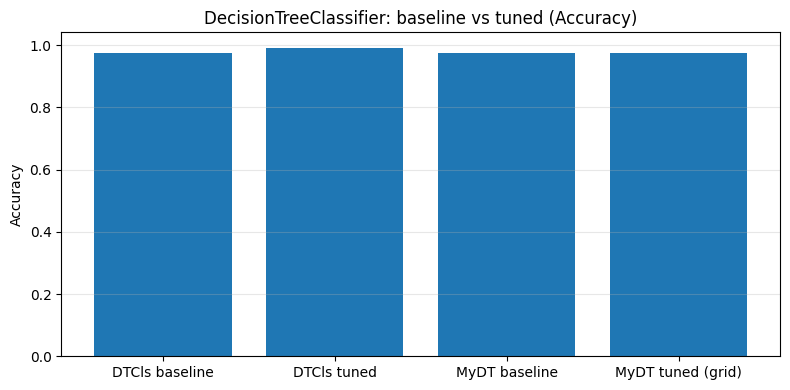

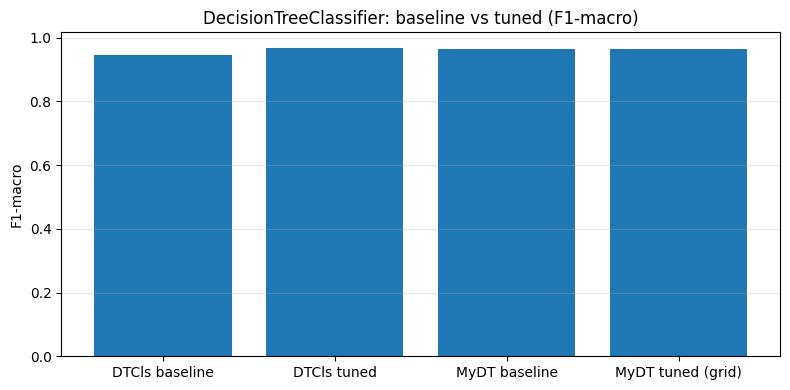

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

def cls_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    return acc, f1m

models_cls = {
    "DTCls baseline": y_pred,
    "DTCls tuned":    yp,
    "MyDT baseline":       y_pred_base_my,
    "MyDT tuned (grid)":   y_pred_tuned_my_cls
}

rows = []
for name, y_hat in models_cls.items():
    acc, f1m = cls_metrics(y_test_cls, y_hat)
    rows.append({"Model": name, "Accuracy": acc, "F1_macro": f1m})

df_cls = pd.DataFrame(rows)
print(df_cls.sort_values("F1_macro", ascending=False))

# ---- Графики ----
plt.figure(figsize=(8, 4))
plt.bar(df_cls["Model"], df_cls["Accuracy"])
plt.ylabel("Accuracy")
plt.title("DecisionTreeClassifier: baseline vs tuned (Accuracy)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(df_cls["Model"], df_cls["F1_macro"])
plt.ylabel("F1-macro")
plt.title("DecisionTreeClassifier: baseline vs tuned (F1-macro)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Своя модель регрессора

In [11]:
import numpy as np

class MyDecisionTreeRegressor:
    class Node:
        def __init__(self, feature_index=None, threshold=None,
                     left=None, right=None, value=None):
            self.feature_index = feature_index  # индекс признака для разбиения
            self.threshold = threshold          # порог по признаку
            self.left = left                    # левый потомок
            self.right = right                  # правый потомок
            self.value = value                  # значение в листе (среднее по y)

        def is_leaf(self):
            return self.value is not None

    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.root = None
        self.n_features_ = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        self.n_features_ = X.shape[1]
        self.root = self._build_tree(X, y, depth=0)

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_row(x, self.root) for x in X])

    def _mse(self, y):
        if len(y) == 0:
            return 0.0
        mean = np.mean(y)
        return np.mean((y - mean) ** 2)

    def _best_split(self, X, y):
        m, n = X.shape
        if m < self.min_samples_split:
            return None, None

        best_feature = None
        best_threshold = None
        best_impurity = float("inf")

        for feature in range(n):
            sorted_idx = np.argsort(X[:, feature])
            Xf = X[sorted_idx, feature]
            yf = y[sorted_idx]

            for i in range(1, m):
                if Xf[i] == Xf[i-1]:
                    continue
                thr = 0.5 * (Xf[i] + Xf[i-1])

                left_y = yf[:i]
                right_y = yf[i:]

                if len(left_y) < self.min_samples_leaf or len(right_y) < self.min_samples_leaf:
                    continue

                mse_left = self._mse(left_y)
                mse_right = self._mse(right_y)
                impurity = (len(left_y) * mse_left + len(right_y) * mse_right) / m

                if impurity < best_impurity:
                    best_impurity = impurity
                    best_feature = feature
                    best_threshold = thr

        return best_feature, best_threshold

    def _build_tree(self, X, y, depth):
        num_samples = len(y)
        if (self.max_depth is not None and depth >= self.max_depth) or \
           num_samples < self.min_samples_split:
            leaf_value = float(np.mean(y))
            return self.Node(value=leaf_value)

        feature, threshold = self._best_split(X, y)
        if feature is None:
            leaf_value = float(np.mean(y))
            return self.Node(value=leaf_value)

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return self.Node(feature_index=feature,
                         threshold=threshold,
                         left=left_child,
                         right=right_child)

    def _predict_row(self, x, node):
        # итеративный спуск по дереву
        while not node.is_leaf():
            if x[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value


Обучим оба бейзлайна

In [16]:
import numpy as np
from itertools import product
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

prep_fitted_reg = dtr_base.named_steps["prep"]

X_train_reg_enc = prep_fitted_reg.transform(X_train_reg)
X_test_reg_enc  = prep_fitted_reg.transform(X_test_reg)

print(X_train_reg_enc.shape, X_test_reg_enc.shape)

my_dtr_base = MyDecisionTreeRegressor(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)
my_dtr_base.fit(X_train_reg_enc, y_train_reg)
y_pred_base_my_reg = my_dtr_base.predict(X_test_reg_enc)

rmse_base = np.sqrt(mean_squared_error(y_test_reg, y_pred_base_my_reg))
mae_base  = mean_absolute_error(y_test_reg, y_pred_base_my_reg)
r2_base   = r2_score(y_test_reg, y_pred_base_my_reg)

print(f"[MyDT Regressor — baseline]   RMSE={rmse_base:.2f} | "
      f"MAE={mae_base:.2f} | R²={r2_base:.4f}")

param_grid_my_reg = {
    "max_depth":        [None, 6, 8, 10, 12],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
}

cv_my_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_tr_reg = X_train_reg_enc
y_tr_reg = np.asarray(y_train_reg)

best_params_my_reg = None
best_rmse_my_reg = np.inf

for max_depth, min_split, min_leaf in product(
    param_grid_my_reg["max_depth"],
    param_grid_my_reg["min_samples_split"],
    param_grid_my_reg["min_samples_leaf"]
):
    rmses = []
    for tr_idx, val_idx in cv_my_reg.split(X_tr_reg):
        reg = MyDecisionTreeRegressor(
            max_depth=max_depth,
            min_samples_split=min_split,
            min_samples_leaf=min_leaf
        )
        reg.fit(X_tr_reg[tr_idx], y_tr_reg[tr_idx])
        y_val_pred = reg.predict(X_tr_reg[val_idx])
        rmses.append(np.sqrt(mean_squared_error(y_tr_reg[val_idx], y_val_pred)))

    mean_rmse = np.mean(rmses)
    if mean_rmse < best_rmse_my_reg:
        best_rmse_my_reg = mean_rmse
        best_params_my_reg = {
            "max_depth": max_depth,
            "min_samples_split": min_split,
            "min_samples_leaf": min_leaf,
        }

print("Best params (MyDT regressor):", best_params_my_reg)
print(f"CV best RMSE (MyDT): {best_rmse_my_reg:.4f}")

my_dtr_tuned = MyDecisionTreeRegressor(**best_params_my_reg)
my_dtr_tuned.fit(X_train_reg_enc, y_train_reg)
y_pred_tuned_my_reg = my_dtr_tuned.predict(X_test_reg_enc)

rmse_tuned = np.sqrt(mean_squared_error(y_test_reg, y_pred_tuned_my_reg))
mae_tuned  = mean_absolute_error(y_test_reg, y_pred_tuned_my_reg)
r2_tuned   = r2_score(y_test_reg, y_pred_tuned_my_reg)

print(f"[MyDT Regressor — tuned]      RMSE={rmse_tuned:.2f} | "
      f"MAE={mae_tuned:.2f} | R²={r2_tuned:.4f}")


(164, 71) (41, 71)
[MyDT Regressor — baseline]   RMSE=2698.79 | MAE=1884.13 | R²=0.9077
Best params (MyDT regressor): {'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 2}
CV best RMSE (MyDT): 2852.2408
[MyDT Regressor — tuned]      RMSE=2717.86 | MAE=1737.66 | R²=0.9064


Посмотрим графики

                  Model           MSE         RMSE          MAE        R²
1      DTReg tuned (sk)  5.168418e+06  2273.415420  1705.925602  0.934531
2      MyDTReg baseline  7.283458e+06  2698.788285  1884.126024  0.907739
3  MyDTReg tuned (grid)  7.386770e+06  2717.861297  1737.659730  0.906430
0   DTReg baseline (sk)  7.551796e+06  2748.053049  1849.154463  0.904340


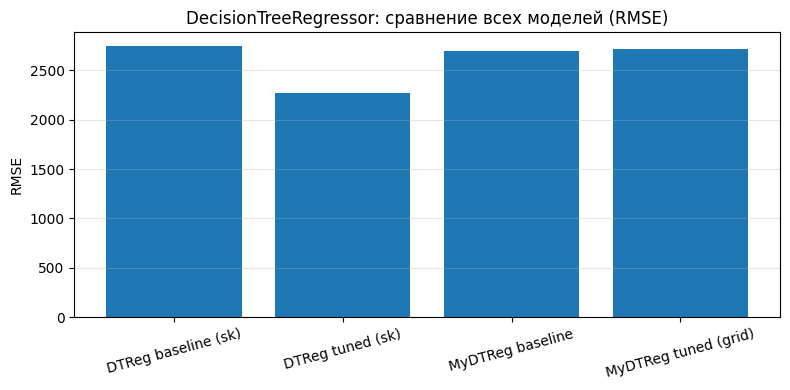

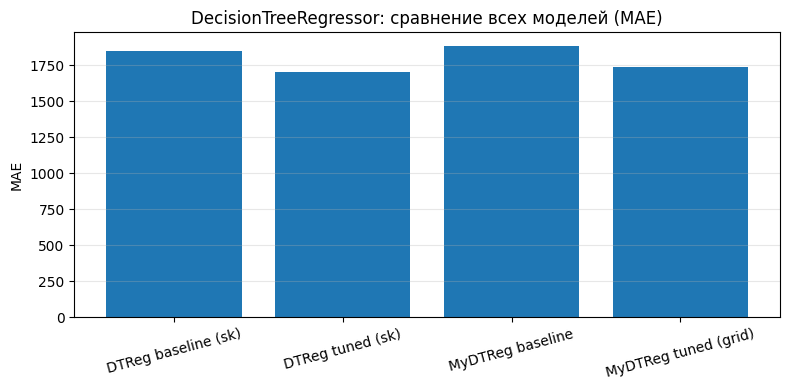

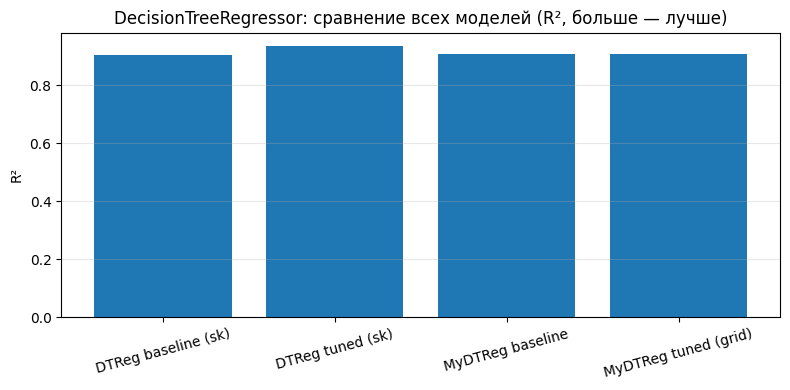

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def reg_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

models_reg = {
    "DTReg baseline (sk)": pred,
    "DTReg tuned (sk)":    p,
    "MyDTReg baseline":    y_pred_base_my_reg,
    "MyDTReg tuned (grid)":y_pred_tuned_my_reg
}

rows = []
for name, y_hat in models_reg.items():
    mse, rmse, mae, r2 = reg_metrics(y_test_reg, y_hat)
    rows.append({"Model": name, "MSE": mse, "RMSE": rmse, "MAE": mae, "R²": r2})

df_reg = pd.DataFrame(rows)
print(df_reg.sort_values("RMSE"))

plt.figure(figsize=(8, 4))
plt.bar(df_reg["Model"], df_reg["RMSE"])
plt.ylabel("RMSE")
plt.title("DecisionTreeRegressor: сравнение всех моделей (RMSE)")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(df_reg["Model"], df_reg["MAE"])
plt.ylabel("MAE")
plt.title("DecisionTreeRegressor: сравнение всех моделей (MAE)")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(df_reg["Model"], df_reg["R²"])
plt.ylabel("R²")
plt.title("DecisionTreeRegressor: сравнение всех моделей (R², больше — лучше)")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
